In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [3]:
# Hyperparameters
input_size = 784
hidden_size = 500
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001


In [4]:
# MNIST dataset 
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)

test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transforms.ToTensor())

# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:02<00:00, 4.76MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 136kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 4.56MB/s]


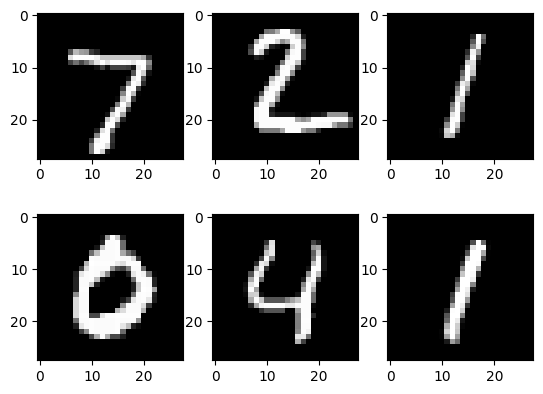

In [5]:
examples = iter(test_loader)
example_data, example_targets = next(examples)

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
plt.show()

In [7]:
##Fully Connected Neural Network with One Hidden Layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.input_size = input_size
        self.l1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes) 

        
    def forward(self, x):
        out = self.l1(x)
        out = self.relu(out)
        out = self.l2(out)
        # no activation and no softmax at the end
        return out
    
model = NeuralNet(input_size, hidden_size, num_classes).to(device) 

In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()  #CrossEntropy has the Softmax Activation Function internally
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  


In [9]:
# Train the Model
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):  
        # origin shape: [100, 1, 28, 28]
        # resized: [100, 784]
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (i+1) % 100 == 0:
            print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

Epoch [1/2], Step [100/600], Loss: 0.4511
Epoch [1/2], Step [200/600], Loss: 0.2430
Epoch [1/2], Step [300/600], Loss: 0.1629
Epoch [1/2], Step [400/600], Loss: 0.1268
Epoch [1/2], Step [500/600], Loss: 0.2219
Epoch [1/2], Step [600/600], Loss: 0.1061
Epoch [2/2], Step [100/600], Loss: 0.1156
Epoch [2/2], Step [200/600], Loss: 0.0841
Epoch [2/2], Step [300/600], Loss: 0.0714
Epoch [2/2], Step [400/600], Loss: 0.0936
Epoch [2/2], Step [500/600], Loss: 0.1825
Epoch [2/2], Step [600/600], Loss: 0.1165


In [10]:
#Test the Model
with torch.no_grad():
    n_correct = 0
    n_samples = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28*28).to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs.data, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network on the 10000 test images: {acc} %')

Accuracy of the network on the 10000 test images: 96.91 %


In [13]:
#Save the Model
PATH = r"C:\Pytorch\CPU\FFNN\model.pth"
torch.save(model.state_dict(), PATH)

## The state_dict() (state dictionary) is a standard Python dictionary object [1]. It maps each layer in your neural network to its corresponding learnable parameters.

In [15]:
#Load the model
PATH = r"C:\Pytorch\CPU\FFNN\model.pth"
model =  NeuralNet(input_size, hidden_size, num_classes)
model.load_state_dict(torch.load(PATH, map_location=torch.device('cpu')))
model.eval()

NeuralNet(
  (l1): Linear(in_features=784, out_features=500, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=500, out_features=10, bias=True)
)

# Testing the Loaded Model

In [17]:
image, true_label = test_dataset[0]

flattened_image = image.view(-1, 28 * 28) 
with torch.no_grad():
    output = model(flattened_image)
    _, predicted_class = torch.max(output, 1)

In [18]:
print(f"True Label: {true_label}")
print(f"Model Prediction: {predicted_class.item()}")

True Label: 7
Model Prediction: 7


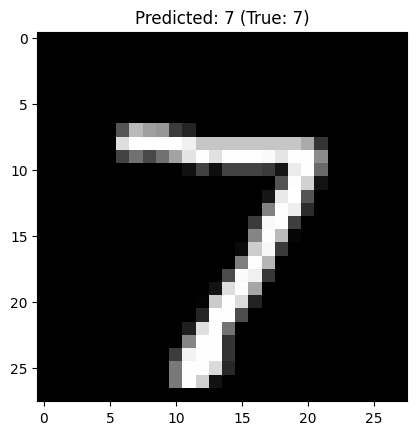

In [19]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_class.item()} (True: {true_label})")
plt.show()